In [1]:
from data_tools.query import DBClient
from data_tools import TimeSeries
import datetime
from zoneinfo import ZoneInfo
import numpy as np
import matplotlib.pyplot as plt
from data_tools import query

In [2]:
tz_van = ZoneInfo("America/Vancouver")

# Local start and end of May 31, 2025
local_start = datetime.datetime(2025, 5, 31, 18, 0, 0, tzinfo=tz_van)
local_end = datetime.datetime(2025, 5, 31, 23, 59, 59, 999999, tzinfo=tz_van)

# Convert to UTC
utc_start = local_start.astimezone(ZoneInfo("UTC"))
utc_end = local_end.astimezone(ZoneInfo("UTC"))

In [3]:
client = DBClient()

gps_latitude_df = client.query_series(utc_start, utc_end, "GPSLatitude", "CAN_log")
gps_longitude_df = client.query_series(utc_start, utc_end, "GPSLongitude", "CAN_log")

latitude_threshold = 123.2
longitude_threshold = 49.2

filtered_gps_indices = np.logical_and(gps_longitude_df.GPSLongitude > longitude_threshold,
                                      gps_latitude_df.GPSLatitude > latitude_threshold)
filtered_gps_latitude_df = gps_latitude_df.loc[filtered_gps_indices]
filtered_gps_longitude_df = gps_longitude_df.loc[filtered_gps_indices]

gps_latitude = TimeSeries.from_query_dataframe(filtered_gps_latitude_df, 0.25, "GPSLatitude", "")
gps_longitude = TimeSeries.from_query_dataframe(filtered_gps_longitude_df, 0.25, "GPSLongitude", "")

C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\data_tools\collections\time_series.py:298: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  query_df['_time'] = pd.to_datetime(query_df['_time'])
C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\data_tools\collections\time_series.py:298: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  query_df['_time'] = pd.to_datetime(query_df['_time'])


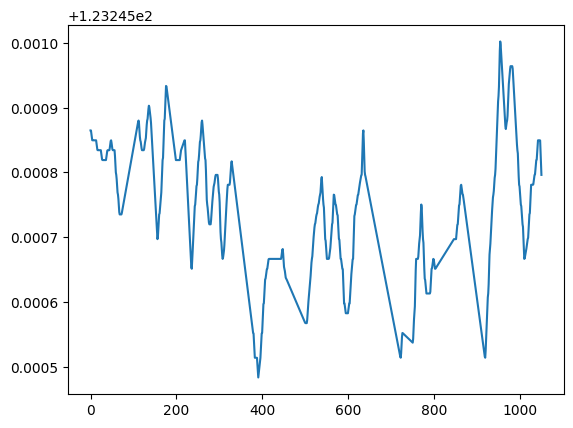

In [4]:
plt.plot(gps_latitude)

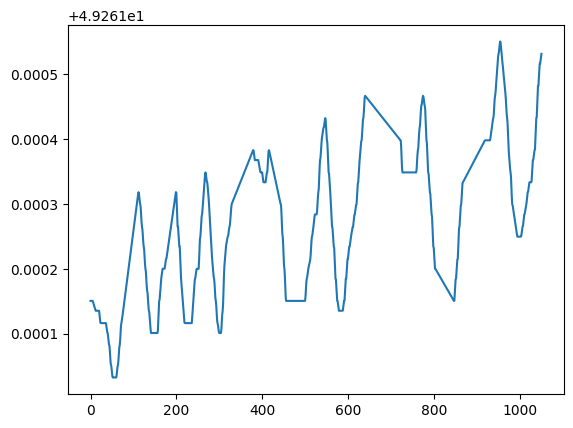

In [5]:
plt.plot(gps_longitude)

i'm borrowing some of Jonah's code to set up things. I am potentially thinking of two different reasons for this lag to occur - buffer still has old values and latency is there, or the latency has to do with how influx is setting up timestamps. potentially go through both hypotheses and fixate.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from data_tools import query, TimeSeries
from datetime import datetime

In [7]:
gps_fields: list[str] = [
    "GPSLatitude", "GPSLongitude", "GPSSatCount", "GPSSNR"
]
# Ignore GPSLatSide and GPSLonSide which say if you're N or S of the equator␣↪and E or W of the Grenwich Meridian
# We're in vancouver so we should leave the latitude sign positive and make␣↪longitude negative.
other_fields: list[str] = [
    "MotorRotatingSpeed"
]
fields_to_query = gps_fields + other_fields

driving_day_start = datetime.fromisoformat("2026-04-02T17:00:00Z")  # 9AM PDT
driving_day_end = datetime.fromisoformat("2026-04-03T01:00:00Z")  # 5PM PDT␣↪(same day in Vancouver)
# 3. Query InfuxDB data
client = query.DBClient()
query_data: dict[str, TimeSeries] = {}
for field in fields_to_query:
    query_data[field] = client.query_time_series(
        driving_day_start,
        driving_day_end,
        field,
    )

In [8]:
 for k, v in query_data.items():
    print(f"{k:20}: start={v.start}, stop={v.stop}, num_points={len(v)}")

GPSLatitude         : start=2026-04-02 11:31:48.892000+00:00, stop=2026-04-02 16:09:23.178000+00:00, num_points=166543
GPSLongitude        : start=2026-04-02 11:31:48.892000+00:00, stop=2026-04-02 16:09:23.178000+00:00, num_points=166543
GPSSatCount         : start=2026-04-02 11:31:48.830000+00:00, stop=2026-04-02 16:09:23.128000+00:00, num_points=166543
GPSSNR              : start=2026-04-02 11:31:48.830000+00:00, stop=2026-04-02 16:09:23.128000+00:00, num_points=166543
MotorRotatingSpeed  : start=2026-04-02 12:17:23.395000+00:00, stop=2026-04-02 16:09:23.315000+00:00, num_points=139200


In [9]:
latitude: TimeSeries = None
longitude: TimeSeries = None
sat_count: TimeSeries = None
gps_snr: TimeSeries = None
speed_kph: TimeSeries = None
latitude, longitude, sat_count, gps_snr, speed_kph = TimeSeries.align(*[query_data[field] for field in fields_to_query])
assert np.all(speed_kph.x_axis == latitude.x_axis)  # Quick alignment check
assert np.all(speed_kph.datetime_x_axis == latitude.datetime_x_axis)
t_axis = speed_kph.x_axis
dt_axis = speed_kph.datetime_x_axis
# Since we are in the western hemisphere, flip the sign on the (unsigned)␣↪latitude value
longitude = -longitude

In [10]:
import pandas as pd

latitude_df: pd.DataFrame = client.query_series(
    driving_day_start,
    driving_day_end,
    "GPSLatitude",
)
longitude_df: pd.DataFrame = client.query_series(
    driving_day_start,
    driving_day_end,
    "GPSLongitude",
)
display(latitude_df)
display(longitude_df)

,result,table,_start,_stop,_time,_measurement,car,class,GPSLatitude
0,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:48.892000+00:00,TEL,Brightside,GPSPosition,0.000000
1,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.145000+00:00,TEL,Brightside,GPSPosition,0.000000
2,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.397000+00:00,TEL,Brightside,GPSPosition,0.000000
3,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.650000+00:00,TEL,Brightside,GPSPosition,0.000000
4,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.902000+00:00,TEL,Brightside,GPSPosition,0.000000
...,...,...,...,...,...,...,...,...,...
29779,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:21.877000+00:00,TEL,Brightside,GPSPosition,0.000000
29780,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:22.421000+00:00,TEL,Brightside,GPSPosition,49.198734
29781,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:22.672000+00:00,TEL,Brightside,GPSPosition,49.198734
29782,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:22.926000+00:00,TEL,Brightside,GPSPosition,49.198734


,result,table,_start,_stop,_time,_measurement,car,class,GPSLongitude
0,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:48.892000+00:00,TEL,Brightside,GPSPosition,0.000000
1,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.145000+00:00,TEL,Brightside,GPSPosition,0.000000
2,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.397000+00:00,TEL,Brightside,GPSPosition,0.000000
3,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.650000+00:00,TEL,Brightside,GPSPosition,0.000000
4,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.902000+00:00,TEL,Brightside,GPSPosition,0.000000
...,...,...,...,...,...,...,...,...,...
29779,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:21.877000+00:00,TEL,Brightside,GPSPosition,0.000000
29780,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:22.421000+00:00,TEL,Brightside,GPSPosition,123.145302
29781,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:22.672000+00:00,TEL,Brightside,GPSPosition,123.145302
29782,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 16:09:22.926000+00:00,TEL,Brightside,GPSPosition,123.145302


In [12]:
phone_gps_df = pd.read_csv('20260402.csv', parse_dates=['time'])
phone_gps_df = phone_gps_df.set_index(pd.to_datetime(phone_gps_df['time'], utc=True)).drop(columns=['time'])
phone_gps_df = phone_gps_df.rename(columns={'lat': 'GPSLatitude', 'lon': 'GPSLongitude'})

phone_gps_df.index = phone_gps_df.index.tz_convert('UTC')

phone_gps_df

,GPSLatitude,GPSLongitude,elevation,accuracy,bearing,speed,satellites,provider,hdop,vdop,...,dgpsid,activity,battery,annotation,timestamp_ms,time_offset,distance,starttimestamp_ms,profile_name,battery_charging
time,,,,,,,,,,,,,,,,,,,,,
2026-04-02 15:37:00.705000+00:00,49.198326,-123.141634,-14.3,29.894,NaN,NaN,0,network,NaN,NaN,...,NaN,NaN,97,NaN,1775144220705,2026-04-02T08:37:00.705-07:00,0.000000,1775144220572,Default Profile,False
2026-04-02 15:37:08.255000+00:00,49.198198,-123.142273,-54.1,10.000,301.11,2.398091,7,gps,2.20,0.96,...,NaN,NaN,97,NaN,1775144228255,2026-04-02T08:37:08.255-07:00,48.546146,1775144220572,Default Profile,False
2026-04-02 15:37:14.051000+00:00,49.198240,-123.142112,-53.8,10.600,292.22,0.131254,6,gps,1.61,0.93,...,NaN,NaN,97,NaN,1775144234051,2026-04-02T08:37:14.051-07:00,61.173478,1775144220572,Default Profile,False
2026-04-02 15:37:19.774000+00:00,49.198258,-123.142022,-61.8,10.500,318.50,2.168525,8,gps,1.54,0.96,...,NaN,NaN,97,NaN,1775144239774,2026-04-02T08:37:19.774-07:00,68.023230,1775144220572,Default Profile,False
2026-04-02 15:37:25.449000+00:00,49.198260,-123.141987,-63.4,10.400,339.27,0.180668,8,gps,1.22,0.84,...,NaN,NaN,97,NaN,1775144245449,2026-04-02T08:37:25.449-07:00,70.573060,1775144220572,Default Profile,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-02 23:15:32+00:00,49.198688,-123.145485,-23.6,1.300,64.14,0.000000,44,gps,0.39,0.52,...,0.0,NaN,80,NaN,1775171732000,2026-04-02T16:15:32.000-07:00,21020.905981,1775144256238,Default Profile,False
2026-04-02 23:15:34+00:00,49.198688,-123.145485,-23.6,1.300,64.14,0.000000,45,gps,0.38,0.52,...,0.0,NaN,80,NaN,1775171734000,2026-04-02T16:15:34.000-07:00,21020.905981,1775144256238,Default Profile,False
2026-04-02 23:15:36+00:00,49.198688,-123.145485,-23.6,1.300,64.14,0.000000,45,gps,0.38,0.52,...,0.0,NaN,80,NaN,1775171736000,2026-04-02T16:15:36.000-07:00,21020.905981,1775144256238,Default Profile,False


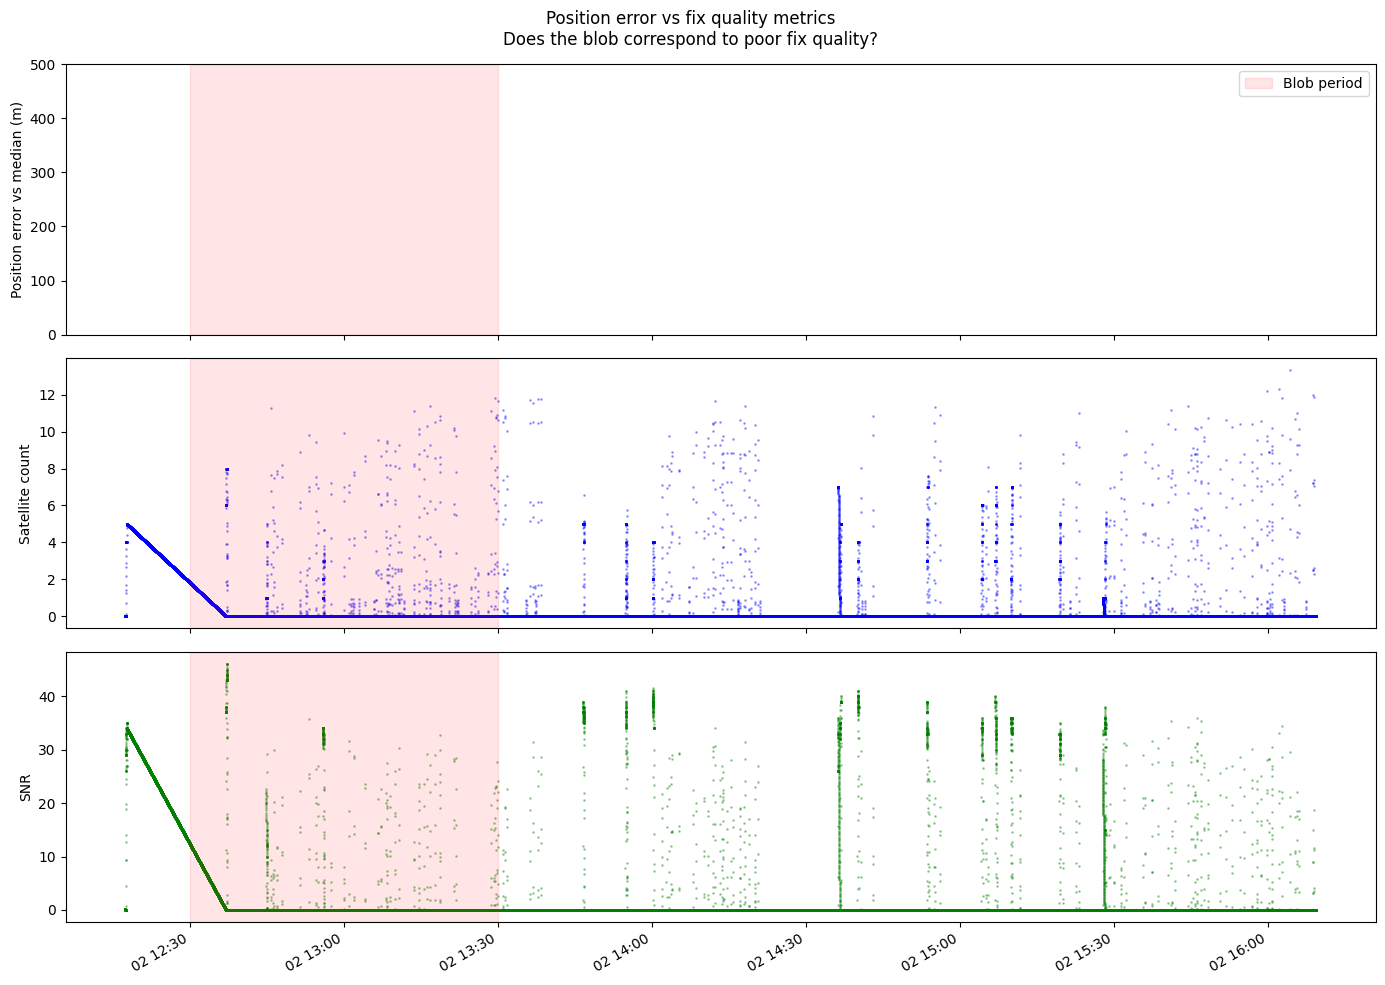

In [14]:
# You'll need to align sat_count and snr onto the same time axis as gps_latlon_df
# They should already be aligned from the earlier TimeSeries.align() call

# Find the time period corresponding to the left blob
# From the map it looks like early in the session — roughly before 13:30 based on
# the speed plot showing early laps

blob_period_start = pd.Timestamp("2026-04-02 12:30:00", tz='UTC')
blob_period_end   = pd.Timestamp("2026-04-02 13:30:00", tz='UTC')

# The known parking lot center from phone GPS (use as ground truth)
TRUE_LAT = phone_gps_df['GPSLatitude'].median()
TRUE_LON = phone_gps_df['GPSLongitude'].median()

# Compute per-sample position error vs phone GPS median (rough proxy)
# For small distances, 1 degree lat ≈ 111km, 1 degree lon ≈ 111km * cos(lat)
import numpy as np

lat_err_m = (latitude_df['GPSLatitude']  - TRUE_LAT) * 111000
lon_err_m = (longitude_df['GPSLongitude'] - TRUE_LON) * 111000 * np.cos(np.radians(TRUE_LAT))
pos_error_m = np.sqrt(lat_err_m**2 + lon_err_m**2)

# Plot position error vs sat count and SNR over time
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].scatter(longitude_df.index, pos_error_m, s=1, alpha=0.3, color='red')
axes[0].axvspan(blob_period_start, blob_period_end, alpha=0.1, color='red', label='Blob period')
axes[0].set_ylabel("Position error vs median (m)")
axes[0].set_ylim(0, 500)
axes[0].legend()

axes[1].scatter(dt_axis, sat_count, s=1, alpha=0.3, color='blue')
axes[1].axvspan(blob_period_start, blob_period_end, alpha=0.1, color='red')
axes[1].set_ylabel("Satellite count")

axes[2].scatter(dt_axis, gps_snr, s=1, alpha=0.3, color='green')
axes[2].axvspan(blob_period_start, blob_period_end, alpha=0.1, color='red')
axes[2].set_ylabel("SNR")

plt.suptitle("Position error vs fix quality metrics\nDoes the blob correspond to poor fix quality?")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [16]:
# Isolate just the blob points — TEL positions far from the phone GPS median
FAR_THRESHOLD_M = 100  # metres — adjust based on what you see

blob_mask = pos_error_m > FAR_THRESHOLD_M

print(f"Blob samples: {blob_mask.sum()} ({blob_mask.mean()*100:.1f}% of session)")
print(f"Blob time range: {latitude_df[blob_mask].index.min()} to {latitude_df[blob_mask].index.max()}")

# What was the sat count and SNR during blob periods?
# Need to align blob_mask onto the sat_count time axis
blob_times = latitude_df[blob_mask].index

print(f"\nBlob position stats:")
print(f"  Lat range: {latitude_df[blob_mask]['GPSLatitude'].min():.6f} to {latitude_df[blob_mask]['GPSLatitude'].max():.6f}")
print(f"  Lon range: {longitude_df[blob_mask]['GPSLongitude'].min():.6f} to {longitude_df[blob_mask]['GPSLongitude'].max():.6f}")
print(f"  Phone GPS median lat: {TRUE_LAT:.6f}")
print(f"  Phone GPS median lon: {TRUE_LON:.6f}")

Blob samples: 29784 (100.0% of session)
Blob time range: 0 to 29783

Blob position stats:
  Lat range: 0.000000 to 49.199333
  Lon range: 0.000000 to 123.146118
  Phone GPS median lat: 49.198747
  Phone GPS median lon: -123.145300


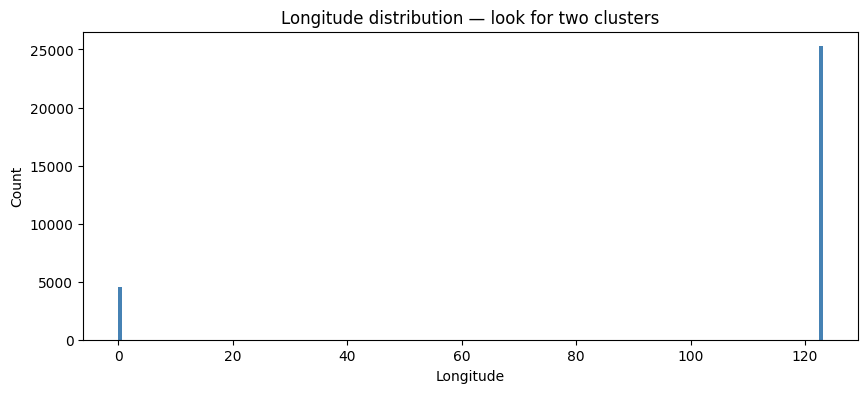

Blob samples: 0
Blob start:   nan
Blob end:     nan


AttributeError: 'float' object has no attribute 'total_seconds'

In [17]:
# The blob is clearly west of the main driving area
# From the map, the blob positions look like they're at a different longitude
# Find the longitude boundary that separates blob from main area

# Plot a longitude histogram to find the natural split
plt.figure(figsize=(10, 4))
plt.hist(longitude_df['GPSLongitude'], bins=200, color='steelblue')
plt.xlabel("Longitude")
plt.ylabel("Count")
plt.title("Longitude distribution — look for two clusters")
plt.show()

# The blob will show as a separate cluster to the left (more negative longitude)
# Pick the boundary from the histogram, then:

BLOB_LON_THRESHOLD = -123.148  # adjust after seeing histogram

blob_mask = longitude_df['GPSLongitude'] < BLOB_LON_THRESHOLD

print(f"Blob samples: {blob_mask.sum()}")
print(f"Blob start:   {longitude_df[blob_mask].index.min()}")
print(f"Blob end:     {longitude_df[blob_mask].index.max()}")
print(f"Duration:     {(longitude_df[blob_mask].index.max() - longitude_df[blob_mask].index.min()).total_seconds():.0f}s")

# Plot blob vs non-blob on timeline
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
gps_latlon_df = longitude_df
axes[0].scatter(gps_latlon_df[~blob_mask].index,
                gps_latlon_df[~blob_mask]['GPSLongitude'],
                s=1, color='steelblue', label='Normal')
axes[0].scatter(gps_latlon_df[blob_mask].index,
                gps_latlon_df[blob_mask]['GPSLongitude'],
                s=1, color='red', label='Blob')
axes[0].set_ylabel("Longitude")
axes[0].legend()

axes[1].scatter(dt_axis, sat_count, s=1, color='green')
axes[1].set_ylabel("Satellite count")

axes[2].scatter(dt_axis, gps_snr, s=1, color='orange')
axes[2].set_ylabel("SNR")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [24]:
from scipy.interpolate import interp1d
import numpy as np

# Interpolate phone GPS onto TEL timestamps
phone_ns  = phone_gps_df.index.astype(np.int64)
tel_ns    = gps_latlon_df.index.astype(np.int64)

f_lat = interp1d(phone_ns, phone_gps_df['GPSLatitude'],
                  bounds_error=False, fill_value=np.nan)
f_lon = interp1d(phone_ns, phone_gps_df['GPSLongitude'],
                  bounds_error=False, fill_value=np.nan)

phone_lat_at_tel_time = f_lat(tel_ns)
phone_lon_at_tel_time = f_lon(tel_ns)

# Convert degree difference to metres
# At Vancouver's latitude (49.2N): 1 deg lat = 111,000m, 1 deg lon = 72,800m
M_PER_DEG_LAT = 111000
M_PER_DEG_LON = 111000 * np.cos(np.radians(49.2))

lat_err_m = (gps_latlon_df['GPSLatitude'].values  - phone_lat_at_tel_time) * M_PER_DEG_LAT
lon_err_m = (gps_latlon_df['GPSLongitude'].values - phone_lon_at_tel_time) * M_PER_DEG_LON

pos_error_m = np.sqrt(lat_err_m**2 + lon_err_m**2)
valid = ~np.isnan(pos_error_m)

# Overall error stats
print("=== Position error: TEL vs Phone (no time correction) ===")
print(f"Median error:      {np.nanmedian(pos_error_m):.1f}m")
print(f"Mean error:        {np.nanmean(pos_error_m):.1f}m")
print(f"95th percentile:   {np.nanpercentile(pos_error_m[valid], 95):.1f}m")
print(f"Max error:         {np.nanmax(pos_error_m):.1f}m")

# Blob vs non-blob breakdown
print("\n=== Blob vs normal periods ===")
print(f"Blob median error:     {np.nanmedian(pos_error_m[blob_mask]):.1f}m")
print(f"Non-blob median error: {np.nanmedian(pos_error_m[~blob_mask]):.1f}m")

# Now apply 39s time correction and recheck
gps_corrected = gps_latlon_df.copy()
gps_corrected.index = gps_corrected.index - pd.Timedelta(seconds=39)
tel_ns_corrected = gps_corrected.index.astype(np.int64)

phone_lat_corrected = f_lat(tel_ns_corrected)
phone_lon_corrected = f_lon(tel_ns_corrected)

lat_err_c = (gps_corrected['GPSLatitude'].values  - phone_lat_corrected) * M_PER_DEG_LAT
lon_err_c = (gps_corrected['GPSLongitude'].values - phone_lon_corrected) * M_PER_DEG_LON
pos_error_corrected = np.sqrt(lat_err_c**2 + lon_err_c**2)

print("\n=== After 39s time correction ===")
print(f"Median error:      {np.nanmedian(pos_error_corrected):.1f}m")
print(f"95th percentile:   {np.nanpercentile(pos_error_corrected[~np.isnan(pos_error_corrected)], 95):.1f}m")
print(f"Max error:         {np.nanmax(pos_error_corrected):.1f}m")
print(f"\nIf median drops significantly, blob was temporal.")
print(f"If median stays high, there is a genuine spatial problem.")

=== Position error: TEL vs Phone (no time correction) ===
Median error:      15.0m
Mean error:        30.7m
95th percentile:   152.7m
Max error:         260.0m

=== Blob vs normal periods ===


IndexError: boolean index did not match indexed array along axis 0; size of axis is 25267 but size of corresponding boolean axis is 29784

In [25]:
# Build everything as a single aligned dataframe so indices always match
error_df = pd.DataFrame({
    'latitude':    gps_latlon_df['GPSLatitude'].values,
    'longitude':   gps_latlon_df['GPSLongitude'].values,
    'pos_error_m': pos_error_m,
    'lat_err_m':   lat_err_m,
    'lon_err_m':   lon_err_m,
}, index=gps_latlon_df.index)

# Recompute blob mask on the same dataframe
BLOB_LON_THRESHOLD = -123.148  # adjust after checking your histogram
error_df['is_blob'] = error_df['longitude'] < BLOB_LON_THRESHOLD

# Drop rows where phone interpolation gave NaN
error_df_valid = error_df.dropna(subset=['pos_error_m'])

print(f"Total samples:         {len(error_df)}")
print(f"Valid (non-NaN) samples: {len(error_df_valid)}")
print(f"Blob samples:          {error_df_valid['is_blob'].sum()}")

print("\n=== Blob vs normal periods ===")
blob    = error_df_valid[error_df_valid['is_blob']]
normal  = error_df_valid[~error_df_valid['is_blob']]

print(f"Blob median error:       {blob['pos_error_m'].median():.1f}m")
print(f"Blob 95th pct error:     {blob['pos_error_m'].quantile(0.95):.1f}m")
print(f"Blob mean lat error:     {blob['lat_err_m'].mean():.1f}m")
print(f"Blob mean lon error:     {blob['lon_err_m'].mean():.1f}m")
print(f"Blob time start:         {blob.index.min()}")
print(f"Blob time end:           {blob.index.max()}")
print(f"Blob duration:           {(blob.index.max() - blob.index.min()).total_seconds():.0f}s")

print(f"\nNormal median error:     {normal['pos_error_m'].median():.1f}m")
print(f"Normal 95th pct error:   {normal['pos_error_m'].quantile(0.95):.1f}m")

# Then recheck after time correction using the same dataframe structure
gps_corrected = gps_latlon_df.copy()
gps_corrected.index = gps_corrected.index - pd.Timedelta(seconds=39)
tel_ns_corrected = gps_corrected.index.astype(np.int64)

phone_lat_corrected = f_lat(tel_ns_corrected)
phone_lon_corrected = f_lon(tel_ns_corrected)

lat_err_c = (gps_corrected['GPSLatitude'].values  - phone_lat_corrected) * M_PER_DEG_LAT
lon_err_c = (gps_corrected['GPSLongitude'].values - phone_lon_corrected) * M_PER_DEG_LON
pos_error_corrected = np.sqrt(lat_err_c**2 + lon_err_c**2)

error_df['pos_error_corrected'] = pos_error_corrected
error_df_valid2 = error_df.dropna(subset=['pos_error_corrected'])

print("\n=== After 39s time correction ===")
print(f"Median error:    {error_df_valid2['pos_error_corrected'].median():.1f}m")
print(f"95th pct:        {error_df_valid2['pos_error_corrected'].quantile(0.95):.1f}m")
print(f"Max error:       {error_df_valid2['pos_error_corrected'].max():.1f}m")

blob_c   = error_df_valid2[error_df_valid2['is_blob']]
normal_c = error_df_valid2[~error_df_valid2['is_blob']]
print(f"\nBlob median error after correction:   {blob_c['pos_error_corrected'].median():.1f}m")
print(f"Normal median error after correction: {normal_c['pos_error_corrected'].median():.1f}m")

Total samples:         25267
Valid (non-NaN) samples: 25267
Blob samples:          0

=== Blob vs normal periods ===
Blob median error:       nanm
Blob 95th pct error:     nanm
Blob mean lat error:     nanm
Blob mean lon error:     nanm
Blob time start:         NaT
Blob time end:           NaT
Blob duration:           nans

Normal median error:     15.0m
Normal 95th pct error:   152.7m

=== After 39s time correction ===
Median error:    23.1m
95th pct:        175.4m
Max error:       259.8m

Blob median error after correction:   nanm
Normal median error after correction: 23.1m


In [ ]:
from scipy.interpolate import interp1d
import numpy as np

# Interpolate phone GPS onto TEL timestamps
phone_ns  = phone_gps_df.index.astype(np.int64)
tel_ns    = gps_latlon_df.index.astype(np.int64)

f_lat = interp1d(phone_ns, phone_gps_df['GPSLatitude'],
                  bounds_error=False, fill_value=np.nan)
f_lon = interp1d(phone_ns, phone_gps_df['GPSLongitude'],
                  bounds_error=False, fill_value=np.nan)

phone_lat_at_tel_time = f_lat(tel_ns)
phone_lon_at_tel_time = f_lon(tel_ns)

# Convert degree difference to metres
# At Vancouver's latitude (49.2N): 1 deg lat = 111,000m, 1 deg lon = 72,800m
M_PER_DEG_LAT = 111000
M_PER_DEG_LON = 111000 * np.cos(np.radians(49.2))

lat_err_m = (gps_latlon_df['GPSLatitude'].values  - phone_lat_at_tel_time) * M_PER_DEG_LAT
lon_err_m = (gps_latlon_df['GPSLongitude'].values - phone_lon_at_tel_time) * M_PER_DEG_LON

pos_error_m = np.sqrt(lat_err_m**2 + lon_err_m**2)
valid = ~np.isnan(pos_error_m)

# Overall error stats
print("=== Position error: TEL vs Phone (no time correction) ===")
print(f"Median error:      {np.nanmedian(pos_error_m):.1f}m")
print(f"Mean error:        {np.nanmean(pos_error_m):.1f}m")
print(f"95th percentile:   {np.nanpercentile(pos_error_m[valid], 95):.1f}m")
print(f"Max error:         {np.nanmax(pos_error_m):.1f}m")

# Blob vs non-blob breakdown
print("\n=== Blob vs normal periods ===")
print(f"Blob median error:     {np.nanmedian(pos_error_m[blob_mask]):.1f}m")
print(f"Non-blob median error: {np.nanmedian(pos_error_m[~blob_mask]):.1f}m")

# Now apply 39s time correction and recheck
gps_corrected = gps_latlon_df.copy()
gps_corrected.index = gps_corrected.index - pd.Timedelta(seconds=39)
tel_ns_corrected = gps_corrected.index.astype(np.int64)

phone_lat_corrected = f_lat(tel_ns_corrected)
phone_lon_corrected = f_lon(tel_ns_corrected)

lat_err_c = (gps_corrected['GPSLatitude'].values  - phone_lat_corrected) * M_PER_DEG_LAT
lon_err_c = (gps_corrected['GPSLongitude'].values - phone_lon_corrected) * M_PER_DEG_LON
pos_error_corrected = np.sqrt(lat_err_c**2 + lon_err_c**2)

print("\n=== After 39s time correction ===")
print(f"Median error:      {np.nanmedian(pos_error_corrected):.1f}m")
print(f"95th percentile:   {np.nanpercentile(pos_error_corrected[~np.isnan(pos_error_corrected)], 95):.1f}m")
print(f"Max error:         {np.nanmax(pos_error_corrected):.1f}m")
print(f"\nIf median drops significantly, blob was temporal.")
print(f"If median stays high, there is a genuine spatial problem.")

In [21]:
assert np.all(latitude_df["_time"] ==longitude_df["_time"])
latitude_df_dtxaxis= latitude_df.set_index(
pd.to_datetime(latitude_df["_time"]).dt.tz_localize(None).dt.tz_localize('Etc/GMT+7').dt.tz_convert('UTC'))
longitude_df_dtxaxis =longitude_df.set_index(pd.to_datetime(longitude_df["_time"]).dt.tz_localize(None).dt.tz_localize('Etc/GMT+7').dt.tz_convert('UTC'))

gps_latlon_df_raw = latitude_df_dtxaxis[["GPSLatitude"]].join(longitude_df_dtxaxis[["GPSLongitude"]], how = 'inner')
gps_latlon_df_raw["GPSLongitude"] = gps_latlon_df_raw["GPSLongitude"]*-1


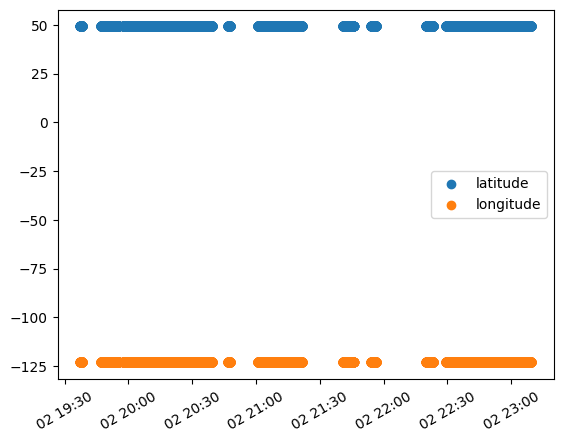

In [22]:
gps_latlon_df = gps_latlon_df_raw[(gps_latlon_df_raw['GPSLatitude'].abs() >= 0.1)
& (gps_latlon_df_raw['GPSLongitude'].abs() >= 0.1)]
fig, ax = plt.subplots()
ax.scatter(gps_latlon_df.index, gps_latlon_df['GPSLatitude'], label='latitude')
ax.scatter(gps_latlon_df.index, gps_latlon_df['GPSLongitude'],label='longitude')
plt.xticks(rotation=30)
plt.legend(loc='best')
plt.show()

In [23]:
gps_latlon_df.head()

,GPSLatitude,GPSLongitude
_time,,
2026-04-02 19:37:22.202000+00:00,49.198933,-123.145332
2026-04-02 19:37:22.454000+00:00,49.198933,-123.145332
2026-04-02 19:37:22.992000+00:00,49.198933,-123.145332
2026-04-02 19:37:23.248000+00:00,49.198933,-123.145332
2026-04-02 19:37:23.500000+00:00,49.198933,-123.145332


In [21]:
latitude_df.head()

,result,table,_start,_stop,_time,_measurement,car,class,GPSLatitude
0,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:48.892000+00:00,TEL,Brightside,GPSPosition,0.0
1,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.145000+00:00,TEL,Brightside,GPSPosition,0.0
2,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.397000+00:00,TEL,Brightside,GPSPosition,0.0
3,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.650000+00:00,TEL,Brightside,GPSPosition,0.0
4,_result,0,2026-04-02 10:00:00+00:00,2026-04-02 18:00:00+00:00,2026-04-02 11:31:49.902000+00:00,TEL,Brightside,GPSPosition,0.0


In [22]:
lat_times = latitude_df["_time"]
diffs = lat_times.diff().dt.total_seconds().dropna()
print(diffs.describe())
print(diffs.value_counts().head(10))



count    29783.000000
mean         0.559188
std         19.159171
min          0.250000
25%          0.252000
50%          0.252000
75%          0.255000
max       2734.049000
Name: _time, dtype: float64
_time
0.252    11889
0.251     5662
0.253     2565
0.254     1720
0.255     1061
0.256      548
0.286      521
0.287      515
0.250      481
0.288      416
Name: count, dtype: int64


In [27]:

utc_time_df = client.query_series(driving_day_start, driving_day_end, "GPSutcTime")


ValueError: Query is empty! Verify that the data is visible on InfluxDB for the queried bucket.

Median interval: 0.252s
Mean interval: 0.559s


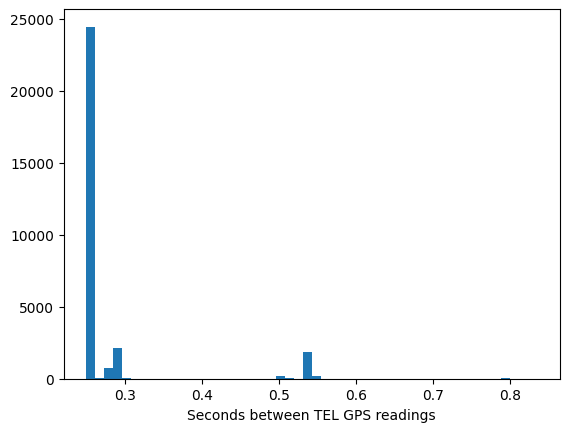

In [28]:
time_diffs = latitude_df["_time"].diff().dt.total_seconds().dropna()
print(f"Median interval: {time_diffs.median():.3f}s")
print(f"Mean interval: {time_diffs.mean():.3f}s")
plt.hist(time_diffs[time_diffs < 2], bins=50)
plt.xlabel("Seconds between TEL GPS readings")
plt.show()

Mean lag: -20905.8s
Std:      17771.25s
Min:      -25240.0s
Max:      58161.0s


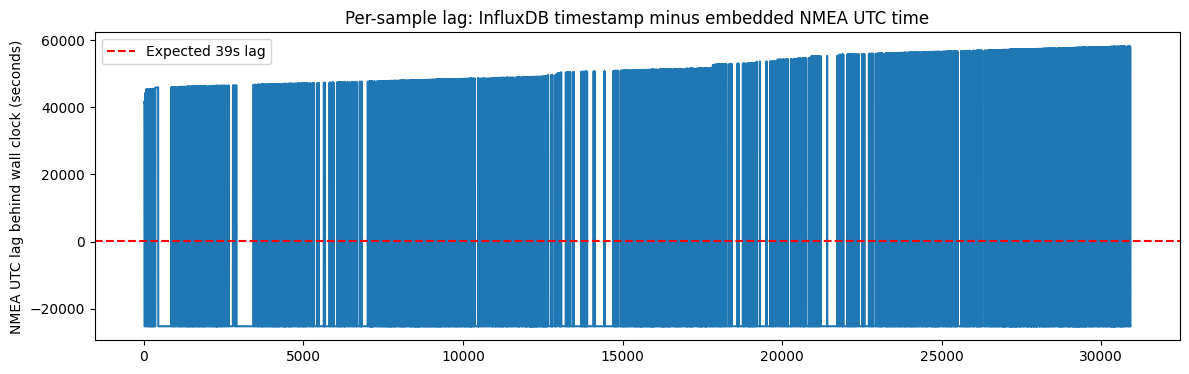

In [40]:
# Query the embedded NMEA UTC time fields
utc_h = client.query_series(driving_day_start, driving_day_end, "GPSHour")   # data[3]
utc_m = client.query_series(driving_day_start, driving_day_end, "GPSMinute") # data[4]
utc_s = client.query_series(driving_day_start, driving_day_end, "GPSSecond") # data[5]

# Reconstruct the embedded UTC time as seconds since midnight
nmea_utc_seconds = utc_h["GPSHour"] * 3600 + utc_m["GPSMinute"] * 60 + utc_s["GPSSecond"]

# Convert InfluxDB wall-clock _time to seconds since midnight UTC
influx_seconds = pd.to_datetime(utc_h["_time"], utc=True).dt.hour * 3600 + \
                 pd.to_datetime(utc_h["_time"], utc=True).dt.minute * 60 + \
                 pd.to_datetime(utc_h["_time"], utc=True).dt.second

# Compute the lag per sample
lag_per_sample = influx_seconds.values - nmea_utc_seconds.values

print(f"Mean lag: {lag_per_sample.mean():.1f}s")
print(f"Std:      {lag_per_sample.std():.2f}s")
print(f"Min:      {lag_per_sample.min():.1f}s")
print(f"Max:      {lag_per_sample.max():.1f}s")

plt.figure(figsize=(14, 4))
plt.plot(lag_per_sample)
plt.axhline(39, color='red', linestyle='--', label='Expected 39s lag')
plt.ylabel("NMEA UTC lag behind wall clock (seconds)")
plt.title("Per-sample lag: InfluxDB timestamp minus embedded NMEA UTC time")
plt.legend()
plt.show()

In [44]:
utc_h_df = client.query_series(driving_day_start, driving_day_end, "GPSHour")
print(utc_h_df.head(20))
print(f"\nUnique GPSHour values: {sorted(utc_h_df['GPSHour'].unique())}")
print(f"InfluxDB _time sample: {utc_h_df['_time'].iloc[0]}")

     result  table                    _start                     _stop  \
0   _result      0 2026-04-02 10:00:00+00:00 2026-04-02 18:00:00+00:00   
1   _result      0 2026-04-02 10:00:00+00:00 2026-04-02 18:00:00+00:00   
2   _result      0 2026-04-02 10:00:00+00:00 2026-04-02 18:00:00+00:00   
3   _result      0 2026-04-02 10:00:00+00:00 2026-04-02 18:00:00+00:00   
4   _result      0 2026-04-02 10:00:00+00:00 2026-04-02 18:00:00+00:00   
5   _result      0 2026-04-02 10:00:00+00:00 2026-04-02 18:00:00+00:00   
6   _result      0 2026-04-02 10:00:00+00:00 2026-04-02 18:00:00+00:00   
7   _result      0 2026-04-02 10:00:00+00:00 2026-04-02 18:00:00+00:00   
8   _result      0 2026-04-02 10:00:00+00:00 2026-04-02 18:00:00+00:00   
9   _result      0 2026-04-02 10:00:00+00:00 2026-04-02 18:00:00+00:00   
10  _result      0 2026-04-02 10:00:00+00:00 2026-04-02 18:00:00+00:00   
11  _result      0 2026-04-02 10:00:00+00:00 2026-04-02 18:00:00+00:00   
12  _result      0 2026-04-02 10:00:00

In [46]:
import pandas as pd
import numpy as np

# Get the raw InfluxDB timestamps as UTC — do NOT apply any tz_localize
influx_times = pd.to_datetime(utc_h_df['_time'], utc=True)

# Extract wall-clock UTC components directly
influx_hour   = influx_times.dt.hour
influx_minute = influx_times.dt.minute
influx_second = influx_times.dt.second

influx_seconds_of_day = influx_hour * 3600 + influx_minute * 60 + influx_second

# Reconstruct NMEA UTC seconds of day from the logged fields
# First verify the fields look right
utc_m_df = client.query_series(driving_day_start, driving_day_end, "GPSMinute")
utc_s_df = client.query_series(driving_day_start, driving_day_end, "GPSSecond")

nmea_seconds_of_day = (utc_h_df['GPSHour'].values * 3600 +
                       utc_m_df['GPSMinute'].values * 60 +
                       utc_s_df['GPSSecond'].values)

print("NMEA UTC hours range:", utc_h_df['GPSHour'].min(), "to", utc_h_df['GPSHour'].max())
print("InfluxDB UTC hours range:", influx_hour.min(), "to", influx_hour.max())
print("\nSample comparison (first 5 rows):")
for i in range(5):
    print(f"  InfluxDB: {influx_hour.iloc[i]:02.0f}:{influx_minute.iloc[i]:02.0f}:{influx_second.iloc[i]:02.0f}"
          f"  NMEA: {utc_h_df['GPSHour'].iloc[i]:02.0f}:{utc_m_df['GPSMinute'].iloc[i]:02.0f}:{utc_s_df['GPSSecond'].iloc[i]:02.0f}")

NMEA UTC hours range: 0.0 to 23.0
InfluxDB UTC hours range: 11 to 16

Sample comparison (first 5 rows):
  InfluxDB: 11:31:48  NMEA: 00:00:00
  InfluxDB: 11:31:49  NMEA: 00:00:00
  InfluxDB: 11:31:49  NMEA: 00:00:00
  InfluxDB: 11:31:49  NMEA: 00:00:00
  InfluxDB: 11:31:49  NMEA: 00:00:00


In [49]:
zero_nmea = (utc_h_df['GPSHour'] == 0) & \
            (utc_m_df['GPSMinute'] == 0) & \
            (utc_s_df['GPSSecond'] == 0)

print(f"Samples with NMEA UTC = 00:00:00: {zero_nmea.sum()} / {len(zero_nmea)}")
print(f"That's {zero_nmea.mean()*100:.1f}% of all samples")

# Check if these correlate with zero lat/lon (i.e. no fix)
# Cross-reference with the latitude data
print(f"\nFirst non-zero NMEA UTC time:")
first_valid = utc_h_df[~zero_nmea].iloc[0]
print(first_valid)

Samples with NMEA UTC = 00:00:00: 1740 / 30917
That's 5.6% of all samples

First non-zero NMEA UTC time:
result                                   _result
table                                          0
_start                 2026-04-02 10:00:00+00:00
_stop                  2026-04-02 18:00:00+00:00
_time           2026-04-02 11:31:52.790000+00:00
_measurement                                 TEL
car                                   Brightside
class                                GPSTimeSide
GPSHour                                     18.0
Name: 14, dtype: object


In [51]:
# Only keep samples where NMEA UTC is non-zero AND lat/lon is non-zero
# These three conditions together mean the module had a valid fix

valid_nmea_time = ~zero_nmea  # NMEA UTC is non-zero

# Also align with the latitude data to cross-check fix status
# Re-index utc_h_df onto the same timestamps as gps_latlon_df
utc_h_aligned = utc_h_df.set_index(pd.to_datetime(utc_h_df['_time'], utc=True))

# Find timestamps where we have valid lat/lon (from gps_latlon_df which already filters zeros)
valid_fix_times = gps_latlon_df.index  # already filtered to non-zero lat/lon

# Filter NMEA UTC data to only valid fix periods
utc_h_valid = utc_h_df[valid_nmea_time].copy()
utc_m_valid = utc_m_df[valid_nmea_time].copy()
utc_s_valid = utc_s_df[valid_nmea_time].copy()

print(f"Samples remaining after filtering: {len(utc_h_valid)}")
print(f"\nSample comparison after filtering (first 5 rows):")

influx_times_valid = pd.to_datetime(utc_h_valid['_time'], utc=True)
for i in range(min(5, len(utc_h_valid))):
    t = influx_times_valid.iloc[i]
    print(f"  InfluxDB: {t.hour:02d}:{t.minute:02d}:{t.second:02d}"
          f"  NMEA: {utc_h_valid['GPSHour'].iloc[i]:02.0f}:"
          f"{utc_m_valid['GPSMinute'].iloc[i]:02.0f}:"
          f"{utc_s_valid['GPSSecond'].iloc[i]:02.0f}")

Samples remaining after filtering: 29177

Sample comparison after filtering (first 5 rows):
  InfluxDB: 11:31:52  NMEA: 18:32:31
  InfluxDB: 11:31:53  NMEA: 18:32:31
  InfluxDB: 11:31:53  NMEA: 18:32:31
  InfluxDB: 11:31:53  NMEA: 18:32:32
  InfluxDB: 11:31:53  NMEA: 18:32:32


Sane samples: 0 / 29177
Mean lag: nans
Std:      nans


C:\Users\sanar\AppData\Local\Temp\ipykernel_15828\3952939581.py:19: RuntimeWarning: Mean of empty slice.
  print(f"Mean lag: {lag[sane].mean():.1f}s")
C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


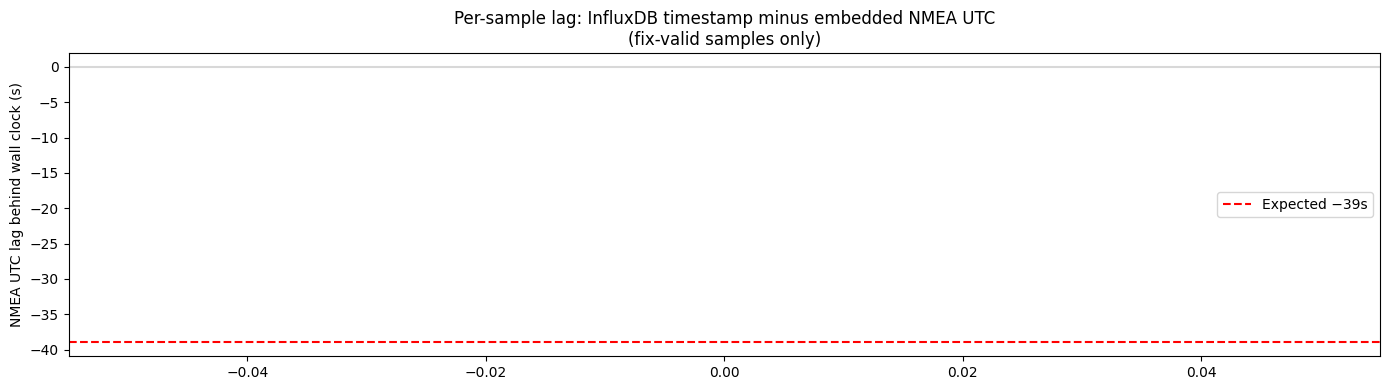

In [53]:
influx_times_v = pd.to_datetime(utc_h_valid['_time'], utc=True)
influx_sod = (influx_times_v.dt.hour * 3600 +
              influx_times_v.dt.minute * 60 +
              influx_times_v.dt.second).values

nmea_sod = (utc_h_valid['GPSHour'].values * 3600 +
            utc_m_valid['GPSMinute'].values * 60 +
            utc_s_valid['GPSSecond'].values)

lag = influx_sod - nmea_sod

# Midnight wraparound correction
lag = np.where(lag >  43200, lag - 86400, lag)
lag = np.where(lag < -43200, lag + 86400, lag)

# Sanity filter — anything beyond ±300s is still a bad sample
sane = (lag > -300) & (lag < 300)
print(f"Sane samples: {sane.sum()} / {len(lag)}")
print(f"Mean lag: {lag[sane].mean():.1f}s")
print(f"Std:      {lag[sane].std():.2f}s")

plt.figure(figsize=(14, 4))
plt.scatter(influx_times_v[sane], lag[sane], s=1, alpha=0.4, color='steelblue')
plt.axhline(-39, color='red', linestyle='--', linewidth=1.5, label='Expected −39s')
plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
plt.ylabel("NMEA UTC lag behind wall clock (s)")
plt.title("Per-sample lag: InfluxDB timestamp minus embedded NMEA UTC\n(fix-valid samples only)")
plt.legend()
plt.tight_layout()
plt.show()

Valid samples: 0 / 30917
Mean lag: nans
Std:      nans


C:\Users\sanar\AppData\Local\Temp\ipykernel_15828\1143129817.py:10: RuntimeWarning: Mean of empty slice.
  print(f"Mean lag: {lag_seconds[valid].mean():.1f}s")
C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\sanar\PycharmProjects\data_analysis\.venv\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


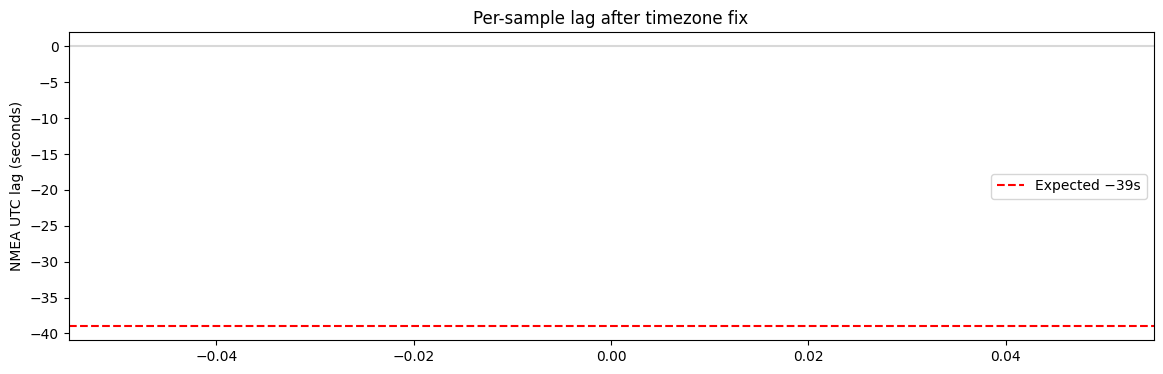

In [47]:
lag_seconds = influx_seconds_of_day.values - nmea_seconds_of_day

# Handle midnight wraparound (e.g. influx=00:00:10, nmea=23:59:31 → should be +39s not -86361s)
lag_seconds = np.where(lag_seconds > 43200,  lag_seconds - 86400, lag_seconds)
lag_seconds = np.where(lag_seconds < -43200, lag_seconds + 86400, lag_seconds)

# Filter to plausible range — anything outside ±300s is a bad sample
valid = (lag_seconds > -300) & (lag_seconds < 300)
print(f"Valid samples: {valid.sum()} / {len(lag_seconds)}")
print(f"Mean lag: {lag_seconds[valid].mean():.1f}s")
print(f"Std:      {lag_seconds[valid].std():.2f}s")

plt.figure(figsize=(14, 4))
plt.plot(influx_times[valid], lag_seconds[valid], linewidth=0.5)
plt.axhline(-39, color='red', linestyle='--', label='Expected −39s')
plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
plt.ylabel("NMEA UTC lag (seconds)")
plt.title("Per-sample lag after timezone fix")
plt.legend()
plt.show()

Sane samples: 29177 / 29177
Mean lag: -38.08s
Std dev:  1.4030s
Min:      -40.00s
Max:      -36.00s


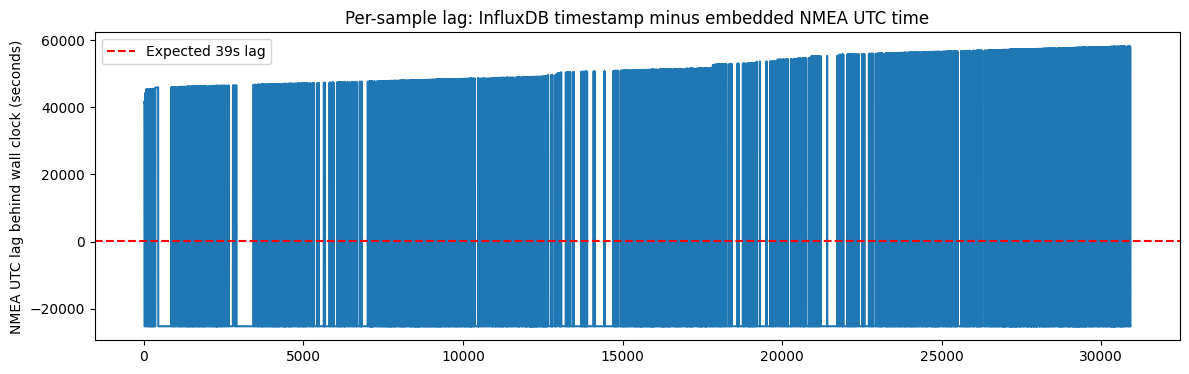

In [59]:
# InfluxDB _time was recorded in PDT (UTC-7), stored as if it were UTC
# Add 7 hours to correct it to true UTC before comparing against NMEA UTC

TIMEZONE_OFFSET_SECONDS = 7 * 3600  # PDT is UTC-7

influx_sod_corrected = influx_sod + TIMEZONE_OFFSET_SECONDS

lag = influx_sod_corrected - nmea_sod

# Midnight wraparound
lag = np.where(lag >  43200, lag - 86400, lag)
lag = np.where(lag < -43200, lag + 86400, lag)

sane = (lag > -300) & (lag < 300)
print(f"Sane samples: {sane.sum()} / {len(lag)}")
print(f"Mean lag: {lag[sane].mean():.2f}s")
print(f"Std dev:  {lag[sane].std():.4f}s")
print(f"Min:      {lag[sane].min():.2f}s")
print(f"Max:      {lag[sane].max():.2f}s")
plt.figure(figsize=(14, 4))
plt.plot(lag_per_sample)
plt.axhline(39, color='red', linestyle='--', label='Expected 39s lag')
plt.ylabel("NMEA UTC lag behind wall clock (seconds)")
plt.title("Per-sample lag") # InfluxDB timestamp minus embedded NMEA UTC time
plt.legend()
plt.show()

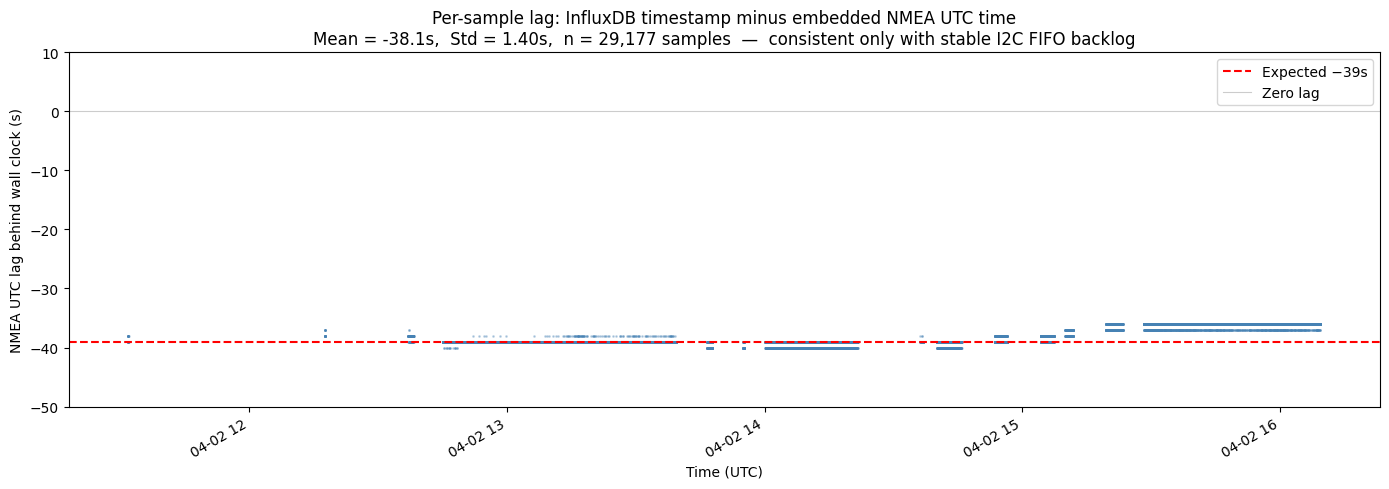

In [60]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(utc_df_valid.index[sane], lag[sane], s=1, alpha=0.3, color='steelblue')
ax.axhline(-39, color='red', linestyle='--', linewidth=1.5, label='Expected −39s')
ax.axhline(0,   color='gray', linestyle='-',  linewidth=0.8, alpha=0.4, label='Zero lag')

ax.set_ylim(-50, 10)
ax.set_ylabel("NMEA UTC lag behind wall clock (s)")
ax.set_xlabel("Time (UTC)")
ax.set_title(
    "Per-sample lag: InfluxDB timestamp minus embedded NMEA UTC time\n"
    f"Mean = {lag[sane].mean():.1f}s,  Std = {lag[sane].std():.2f}s,  "
    f"n = {sane.sum():,} samples  —  consistent only with stable I2C FIFO backlog"
)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [58]:
# Rebuild as single dataframe to guarantee alignment
utc_df = pd.DataFrame({
    'hour':   utc_h_df['GPSHour'].values,
    'minute': utc_m_df['GPSMinute'].values,
    'second': utc_s_df['GPSSecond'].values,
}, index=pd.to_datetime(utc_h_df['_time'], utc=True))

# Filter out no-fix zeroes as a single operation
utc_df_valid = utc_df[(utc_df['hour'] != 0) |
                       (utc_df['minute'] != 0) |
                       (utc_df['second'] != 0)]

print(f"Samples after filter: {len(utc_df_valid)}")
print(utc_df_valid.head(10))

# Recompute lag from the clean aligned dataframe
influx_sod = (utc_df_valid.index.hour * 3600 +
              utc_df_valid.index.minute * 60 +
              utc_df_valid.index.second)

nmea_sod = (utc_df_valid['hour'] * 3600 +
            utc_df_valid['minute'] * 60 +
            utc_df_valid['second'])

lag = (influx_sod - nmea_sod).values

lag = np.where(lag >  43200, lag - 86400, lag)
lag = np.where(lag < -43200, lag + 86400, lag)

sane = (lag > -300) & (lag < 300)
print(f"\nSane samples: {sane.sum()} / {len(lag)}")

if sane.sum() > 0:
    print(f"Mean lag: {lag[sane].mean():.2f}s")
    print(f"Std dev:  {lag[sane].std():.4f}s")
    print(f"Min:      {lag[sane].min():.2f}s")
    print(f"Max:      {lag[sane].max():.2f}s")

    plt.figure(figsize=(14, 5))
    plt.scatter(utc_df_valid.index[sane], lag[sane], s=1, alpha=0.4, color='steelblue')
    plt.axhline(-39, color='red', linestyle='--', linewidth=1.5, label='Expected −39s')
    plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
    plt.ylabel("NMEA UTC lag behind wall clock (s)")
    plt.xlabel("Time (UTC)")
    plt.title("Per-sample lag: InfluxDB timestamp minus embedded NMEA UTC\n"
              "(fix-valid samples only)")
    plt.ylim(-50, 10)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("\nStill no sane samples — print lag[:20] to see raw values")
    print(lag[:20])

Samples after filter: 29177
                                  hour  minute  second
_time                                                 
2026-04-02 11:31:52.790000+00:00  18.0    32.0    31.0
2026-04-02 11:31:53.042000+00:00  18.0    32.0    31.0
2026-04-02 11:31:53.294000+00:00  18.0    32.0    31.0
2026-04-02 11:31:53.546000+00:00  18.0    32.0    32.0
2026-04-02 11:31:53.797000+00:00  18.0    32.0    32.0
2026-04-02 11:31:54.049000+00:00  18.0    32.0    32.0
2026-04-02 11:31:54.301000+00:00  18.0    32.0    32.0
2026-04-02 11:31:54.553000+00:00  18.0    32.0    33.0
2026-04-02 11:31:54.839000+00:00  18.0    32.0    33.0
2026-04-02 11:31:55.091000+00:00  18.0    32.0    33.0

Sane samples: 0 / 29177

Still no sane samples — print lag[:20] to see raw values
[-25239. -25238. -25238. -25239. -25239. -25238. -25238. -25239. -25239.
 -25238. -25238. -25239. -25239. -25238. -25238. -25239. -25239. -25238.
 -25238. -25239.]


In [37]:
utc_h:pd.DataFrame = client.query_series(driving_day_start, driving_day_end, "GPSHour")   # data[3]
utc_m:pd.DataFrame = client.query_series(driving_day_start, driving_day_end, "GPSMinute") # data[4]
utc_s:pd.DataFrame = client.query_series(driving_day_start, driving_day_end, "GPSSecond") # data[5]

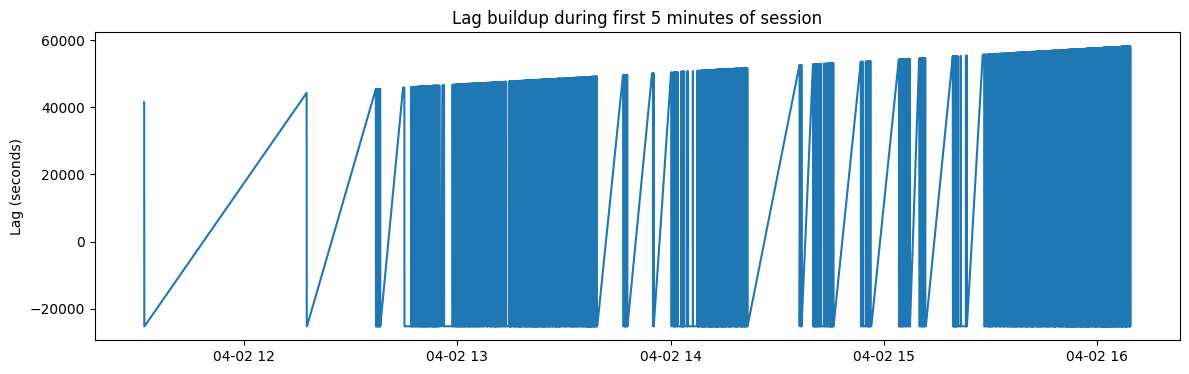

In [61]:
session_start = gps_latlon_df.index.min()
first_5min = session_start + pd.Timedelta(minutes=5)

early_lag = lag_per_sample[utc_h["_time"] < first_5min]
early_times = pd.to_datetime(utc_h["_time"], utc=True)[utc_h["_time"] < first_5min]

plt.figure(figsize=(14, 4))
plt.plot(early_times, early_lag)
plt.ylabel("Lag (seconds)")
plt.title("Lag buildup during first 5 minutes of session")
plt.show()